#*WEEK 1 - Data Set up and Cleaning*

# Importing necessary libraries and datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
appointment = pd.read_csv("/content/appointments.csv")
billing = pd.read_csv("/content/billing.csv")
doctor = pd.read_csv("/content/doctors.csv")
patient = pd.read_csv("/content/patients.csv")
treatment = pd.read_csv("/content/treatments.csv")

In [3]:
print(appointment.shape)
print(billing.shape)
print(doctor.shape)
print(patient.shape)
print(treatment.shape)

(200, 7)
(200, 7)
(10, 8)
(50, 11)
(200, 6)


In [4]:
appointment.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [5]:
billing.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending


In [6]:
doctor.head()

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [7]:
patient.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [8]:
treatment.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


# merging the table into one table

In [9]:
merged_table = pd.merge(treatment, appointment, on='appointment_id', how="left")
merged_table.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [10]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   treatment_id      200 non-null    object 
 1   appointment_id    200 non-null    object 
 2   treatment_type    200 non-null    object 
 3   description       200 non-null    object 
 4   cost              200 non-null    float64
 5   treatment_date    200 non-null    object 
 6   patient_id        200 non-null    object 
 7   doctor_id         200 non-null    object 
 8   appointment_date  200 non-null    object 
 9   appointment_time  200 non-null    object 
 10  reason_for_visit  200 non-null    object 
 11  status            200 non-null    object 
dtypes: float64(1), object(11)
memory usage: 18.9+ KB


In [11]:
billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bill_id         200 non-null    object 
 1   patient_id      200 non-null    object 
 2   treatment_id    200 non-null    object 
 3   bill_date       200 non-null    object 
 4   amount          200 non-null    float64
 5   payment_method  200 non-null    object 
 6   payment_status  200 non-null    object 
dtypes: float64(1), object(6)
memory usage: 11.1+ KB


In [12]:
merged_table = pd.merge(merged_table, billing.drop(["bill_id","patient_id","bill_date","amount","payment_status","payment_method"],axis = 1), on='treatment_id', how="left")
merged_table.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [13]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   treatment_id      200 non-null    object 
 1   appointment_id    200 non-null    object 
 2   treatment_type    200 non-null    object 
 3   description       200 non-null    object 
 4   cost              200 non-null    float64
 5   treatment_date    200 non-null    object 
 6   patient_id        200 non-null    object 
 7   doctor_id         200 non-null    object 
 8   appointment_date  200 non-null    object 
 9   appointment_time  200 non-null    object 
 10  reason_for_visit  200 non-null    object 
 11  status            200 non-null    object 
dtypes: float64(1), object(11)
memory usage: 18.9+ KB


In [14]:
patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          50 non-null     object
 1   first_name          50 non-null     object
 2   last_name           50 non-null     object
 3   gender              50 non-null     object
 4   date_of_birth       50 non-null     object
 5   contact_number      50 non-null     int64 
 6   address             50 non-null     object
 7   registration_date   50 non-null     object
 8   insurance_provider  50 non-null     object
 9   insurance_number    50 non-null     object
 10  email               50 non-null     object
dtypes: int64(1), object(10)
memory usage: 4.4+ KB


In [15]:
# converting the date of birth column to age

patient["age"] = 2023 - pd.to_datetime(patient["date_of_birth"]).dt.year
patient.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email,age
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,68
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com,39
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com,46
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com,42
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com,63


In [16]:
merged_table = pd.merge(merged_table, patient.drop(["first_name","last_name","date_of_birth","contact_number","address","email","insurance_number","insurance_provider"],axis = 1), on = "patient_id", how ="left")
merged_table.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,gender,registration_date,age
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,F,2023-06-18,73
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09,P032,D004,2023-06-09,14:30:00,Therapy,No-show,M,2021-10-02,42
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,M,2023-06-19,40
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,M,2021-09-09,57
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06,P040,D003,2023-07-06,12:45:00,Emergency,No-show,M,2021-10-16,51


In [17]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   treatment_id       200 non-null    object 
 1   appointment_id     200 non-null    object 
 2   treatment_type     200 non-null    object 
 3   description        200 non-null    object 
 4   cost               200 non-null    float64
 5   treatment_date     200 non-null    object 
 6   patient_id         200 non-null    object 
 7   doctor_id          200 non-null    object 
 8   appointment_date   200 non-null    object 
 9   appointment_time   200 non-null    object 
 10  reason_for_visit   200 non-null    object 
 11  status             200 non-null    object 
 12  gender             200 non-null    object 
 13  registration_date  200 non-null    object 
 14  age                200 non-null    int32  
dtypes: float64(1), int32(1), object(13)
memory usage: 22.8+ KB


In [18]:
doctor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   doctor_id         10 non-null     object
 1   first_name        10 non-null     object
 2   last_name         10 non-null     object
 3   specialization    10 non-null     object
 4   phone_number      10 non-null     int64 
 5   years_experience  10 non-null     int64 
 6   hospital_branch   10 non-null     object
 7   email             10 non-null     object
dtypes: int64(2), object(6)
memory usage: 772.0+ bytes


In [19]:
merged_table = pd.merge(merged_table, doctor.drop(["phone_number","email","hospital_branch"],axis = 1), on = "doctor_id", how ="left")
merged_table.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,gender,registration_date,age,first_name,last_name,specialization,years_experience
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,F,2023-06-18,73,Sarah,Smith,Pediatrics,26
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09,P032,D004,2023-06-09,14:30:00,Therapy,No-show,M,2021-10-02,42,David,Jones,Pediatrics,28
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,M,2023-06-19,40,David,Jones,Pediatrics,28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,M,2021-09-09,57,Alex,Davis,Pediatrics,23
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06,P040,D003,2023-07-06,12:45:00,Emergency,No-show,M,2021-10-16,51,Jane,Smith,Pediatrics,19


In [20]:
merged_table.rename(columns={"first_name":"doctor_first_name","last_name":"doctor_last_name","status":"appointment_status","description":"treatment_description","age":"patient_age","specialization":"doctor_spaecialization","years_experience":"doctor_year_of_experience"}, inplace = True)
merged_table.head()

,treatment_id,appointment_id,treatment_type,treatment_description,cost,treatment_date,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,appointment_status,gender,registration_date,patient_age,doctor_first_name,doctor_last_name,doctor_spaecialization,doctor_year_of_experience
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,F,2023-06-18,73,Sarah,Smith,Pediatrics,26
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09,P032,D004,2023-06-09,14:30:00,Therapy,No-show,M,2021-10-02,42,David,Jones,Pediatrics,28
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,M,2023-06-19,40,David,Jones,Pediatrics,28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,M,2021-09-09,57,Alex,Davis,Pediatrics,23
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06,P040,D003,2023-07-06,12:45:00,Emergency,No-show,M,2021-10-16,51,Jane,Smith,Pediatrics,19


In [21]:
merged_table.rename(columns={"gender":"patient_gender"}, inplace = True)
merged_table.head()

,treatment_id,appointment_id,treatment_type,treatment_description,cost,treatment_date,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,appointment_status,patient_gender,registration_date,patient_age,doctor_first_name,doctor_last_name,doctor_spaecialization,doctor_year_of_experience
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,F,2023-06-18,73,Sarah,Smith,Pediatrics,26
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09,P032,D004,2023-06-09,14:30:00,Therapy,No-show,M,2021-10-02,42,David,Jones,Pediatrics,28
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,M,2023-06-19,40,David,Jones,Pediatrics,28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,M,2021-09-09,57,Alex,Davis,Pediatrics,23
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06,P040,D003,2023-07-06,12:45:00,Emergency,No-show,M,2021-10-16,51,Jane,Smith,Pediatrics,19


In [22]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   appointment_id             200 non-null    object 
 2   treatment_type             200 non-null    object 
 3   treatment_description      200 non-null    object 
 4   cost                       200 non-null    float64
 5   treatment_date             200 non-null    object 
 6   patient_id                 200 non-null    object 
 7   doctor_id                  200 non-null    object 
 8   appointment_date           200 non-null    object 
 9   appointment_time           200 non-null    object 
 10  reason_for_visit           200 non-null    object 
 11  appointment_status         200 non-null    object 
 12  patient_gender             200 non-null    object 
 13  registration_date          200 non-null    object 

In [23]:
columns = merged_table.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {merged_table[columns[i]].unique()}\n")

treatment_id values are 
 ['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120'
 'T121' 'T122' 'T123' 'T124' 'T125' 'T126' 'T127' 'T128' 'T129' 'T130'
 'T131' 'T132' 'T133' 'T134' 'T135' 'T136' 'T137' '

# deriving the recovery_status, recovery_duration, diseases_name from the existing columns

In [24]:
def map_disease(treatment, reason):
    if treatment == 'Chemotherapy':
        return 'Cancer'
    elif treatment == 'MRI':
        return 'Brain Tumor' if reason != 'Checkup' else 'Headache'
    elif treatment == 'ECG':
        return 'Heart Disease'
    elif treatment == 'Physiotherapy':
        return 'Muscle Pain'
    elif treatment == 'X-Ray':
        return 'Bone Fracture'
    else:
        return 'General Illness'

In [25]:
def map_recovery_duration(treatment, desc):
    if treatment == 'Chemotherapy':
        return 180 if desc == 'Advanced protocol' else 150
    elif treatment == 'MRI':
        return 10
    elif treatment == 'ECG':
        return 7
    elif treatment == 'Physiotherapy':
        return 30
    elif treatment == 'X-Ray':
        return 14


In [26]:
def map_recovery_status(appointment_status, duration):
    if appointment_status == 'Completed':
        if duration <= 14:
            return 'Recovered'
        elif duration <= 60:
            return 'Improving'
        else:
            return 'Under Treatment'
    elif appointment_status in ['Cancelled', 'No-show']:
        return 'Not Treated'
    else:
        return 'In Progress'


In [27]:
merged_table['disease_name'] = merged_table.apply(lambda x: map_disease(x['treatment_type'], x['reason_for_visit']), axis=1)
merged_table['recovery_duration'] = merged_table.apply(lambda x: map_recovery_duration(x['treatment_type'], x['treatment_description']), axis=1)
merged_table['recovery_status'] = merged_table.apply(lambda x: map_recovery_status(x['appointment_status'], x['recovery_duration']), axis=1)


In [28]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   appointment_id             200 non-null    object 
 2   treatment_type             200 non-null    object 
 3   treatment_description      200 non-null    object 
 4   cost                       200 non-null    float64
 5   treatment_date             200 non-null    object 
 6   patient_id                 200 non-null    object 
 7   doctor_id                  200 non-null    object 
 8   appointment_date           200 non-null    object 
 9   appointment_time           200 non-null    object 
 10  reason_for_visit           200 non-null    object 
 11  appointment_status         200 non-null    object 
 12  patient_gender             200 non-null    object 
 13  registration_date          200 non-null    object 

In [29]:
columns = merged_table.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {merged_table[columns[i]].unique()}\n")

treatment_id values are 
 ['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120'
 'T121' 'T122' 'T123' 'T124' 'T125' 'T126' 'T127' 'T128' 'T129' 'T130'
 'T131' 'T132' 'T133' 'T134' 'T135' 'T136' 'T137' '

In [30]:
# dropping the unwanted columns after using them to drive the required column

merged_table.drop(["registration_date","appointment_time","treatment_description","reason_for_visit"], axis = 1, inplace = True)

In [31]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   appointment_id             200 non-null    object 
 2   treatment_type             200 non-null    object 
 3   cost                       200 non-null    float64
 4   treatment_date             200 non-null    object 
 5   patient_id                 200 non-null    object 
 6   doctor_id                  200 non-null    object 
 7   appointment_date           200 non-null    object 
 8   appointment_status         200 non-null    object 
 9   patient_gender             200 non-null    object 
 10  patient_age                200 non-null    int32  
 11  doctor_first_name          200 non-null    object 
 12  doctor_last_name           200 non-null    object 
 13  doctor_spaecialization     200 non-null    object 

In [32]:
# checking for the colums having same value but different column name and then dropping the duplicate one

columns = merged_table.columns
for i in range(len(columns)):
    for j in range(i+1, len(columns)):
        if merged_table[columns[i]].equals(merged_table[columns[j]]):
            print(f"{columns[i]} and {columns[j]} are same")


treatment_date and appointment_date are same


In [33]:
merged_table.drop("treatment_date", axis = 1, inplace = True)

In [34]:
merged_table.drop("appointment_date", axis = 1, inplace = True)

In [35]:
columns = merged_table.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {merged_table[columns[i]].unique()}\n")

treatment_id values are 
 ['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120'
 'T121' 'T122' 'T123' 'T124' 'T125' 'T126' 'T127' 'T128' 'T129' 'T130'
 'T131' 'T132' 'T133' 'T134' 'T135' 'T136' 'T137' '

In [36]:
from google.colab import files

merged_table.to_csv('cleaned_medical_data.csv', index=False)

files.download('cleaned_medical_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# *WEEK 2 Exploratory Data Analysis (EDA)*

In [37]:
new_data = pd.read_csv("/content/cleaned_medical_data.csv")
summary_all = new_data.describe(include='all')
print(summary_all)


       treatment_id appointment_id treatment_type         cost patient_id  \
count           200            200            200   200.000000        200   
unique          200            200              5          NaN         48   
top            T001           A001   Chemotherapy          NaN       P012   
freq              1              1             49          NaN         10   
mean            NaN            NaN            NaN  2756.249250        NaN   
std             NaN            NaN            NaN  1298.125308        NaN   
min             NaN            NaN            NaN   534.030000        NaN   
25%             NaN            NaN            NaN  1563.412500        NaN   
50%             NaN            NaN            NaN  2828.165000        NaN   
75%             NaN            NaN            NaN  3836.627500        NaN   
max             NaN            NaN            NaN  4973.630000        NaN   

       doctor_id appointment_status patient_gender  patient_age  \
count   

In [38]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   appointment_id             200 non-null    object 
 2   treatment_type             200 non-null    object 
 3   cost                       200 non-null    float64
 4   patient_id                 200 non-null    object 
 5   doctor_id                  200 non-null    object 
 6   appointment_status         200 non-null    object 
 7   patient_gender             200 non-null    object 
 8   patient_age                200 non-null    int64  
 9   doctor_first_name          200 non-null    object 
 10  doctor_last_name           200 non-null    object 
 11  doctor_spaecialization     200 non-null    object 
 12  doctor_year_of_experience  200 non-null    int64  
 13  disease_name               200 non-null    object 

In [39]:
new_data.head()

,treatment_id,appointment_id,treatment_type,cost,patient_id,doctor_id,appointment_status,patient_gender,patient_age,doctor_first_name,doctor_last_name,doctor_spaecialization,doctor_year_of_experience,disease_name,recovery_duration,recovery_status
0,T001,A001,Chemotherapy,3941.97,P034,D009,Scheduled,F,73,Sarah,Smith,Pediatrics,26,Cancer,150,In Progress
1,T002,A002,MRI,4158.44,P032,D004,No-show,M,42,David,Jones,Pediatrics,28,Brain Tumor,10,Not Treated
2,T003,A003,MRI,3731.55,P048,D004,Cancelled,M,40,David,Jones,Pediatrics,28,Brain Tumor,10,Not Treated
3,T004,A004,MRI,4799.86,P025,D006,Cancelled,M,57,Alex,Davis,Pediatrics,23,Brain Tumor,10,Not Treated
4,T005,A005,ECG,582.05,P040,D003,No-show,M,51,Jane,Smith,Pediatrics,19,Heart Disease,7,Not Treated


In [40]:
new_data.shape

(200, 16)

In [41]:
new_data.isnull().sum()

,0
treatment_id,0
appointment_id,0
treatment_type,0
cost,0
patient_id,0
doctor_id,0
appointment_status,0
patient_gender,0
patient_age,0
doctor_first_name,0


In [42]:
obj_columns = new_data.select_dtypes(include=['object']).columns
print(obj_columns)

Index(['treatment_id', 'appointment_id', 'treatment_type', 'patient_id',
       'doctor_id', 'appointment_status', 'patient_gender',
       'doctor_first_name', 'doctor_last_name', 'doctor_spaecialization',
       'disease_name', 'recovery_status'],
      dtype='object')


In [43]:
new_data["treatment_id"].unique().shape

(200,)

In [44]:
new_data["appointment_id"].unique().shape

(200,)

In [45]:
columns = new_data.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {new_data[columns[i]].unique()}\n")

treatment_id values are 
 ['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120'
 'T121' 'T122' 'T123' 'T124' 'T125' 'T126' 'T127' 'T128' 'T129' 'T130'
 'T131' 'T132' 'T133' 'T134' 'T135' 'T136' 'T137' '

In [46]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   appointment_id             200 non-null    object 
 2   treatment_type             200 non-null    object 
 3   cost                       200 non-null    float64
 4   patient_id                 200 non-null    object 
 5   doctor_id                  200 non-null    object 
 6   appointment_status         200 non-null    object 
 7   patient_gender             200 non-null    object 
 8   patient_age                200 non-null    int64  
 9   doctor_first_name          200 non-null    object 
 10  doctor_last_name           200 non-null    object 
 11  doctor_spaecialization     200 non-null    object 
 12  doctor_year_of_experience  200 non-null    int64  
 13  disease_name               200 non-null    object 

dropping more features in order to train the model for specific task

In [47]:
new_data.drop(["appointment_id","patient_id","doctor_id","doctor_first_name","doctor_last_name"], axis = 1, inplace = True)


In [48]:
new_data.head()

,treatment_id,treatment_type,cost,appointment_status,patient_gender,patient_age,doctor_spaecialization,doctor_year_of_experience,disease_name,recovery_duration,recovery_status
0,T001,Chemotherapy,3941.97,Scheduled,F,73,Pediatrics,26,Cancer,150,In Progress
1,T002,MRI,4158.44,No-show,M,42,Pediatrics,28,Brain Tumor,10,Not Treated
2,T003,MRI,3731.55,Cancelled,M,40,Pediatrics,28,Brain Tumor,10,Not Treated
3,T004,MRI,4799.86,Cancelled,M,57,Pediatrics,23,Brain Tumor,10,Not Treated
4,T005,ECG,582.05,No-show,M,51,Pediatrics,19,Heart Disease,7,Not Treated


In [49]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   treatment_type             200 non-null    object 
 2   cost                       200 non-null    float64
 3   appointment_status         200 non-null    object 
 4   patient_gender             200 non-null    object 
 5   patient_age                200 non-null    int64  
 6   doctor_spaecialization     200 non-null    object 
 7   doctor_year_of_experience  200 non-null    int64  
 8   disease_name               200 non-null    object 
 9   recovery_duration          200 non-null    int64  
 10  recovery_status            200 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 17.3+ KB


In [50]:
#Summary statistics for numeric fields
summary = new_data.describe()
print(summary)


              cost  patient_age  doctor_year_of_experience  recovery_duration
count   200.000000   200.000000                 200.000000         200.000000
mean   2756.249250    40.745000                  21.520000          49.950000
std    1298.125308    16.085512                   5.920716          62.131224
min     534.030000    18.000000                   5.000000           7.000000
25%    1563.412500    29.000000                  19.000000          10.000000
50%    2828.165000    36.000000                  23.000000          14.000000
75%    3836.627500    53.000000                  26.000000          30.000000
max    4973.630000    73.000000                  28.000000         180.000000


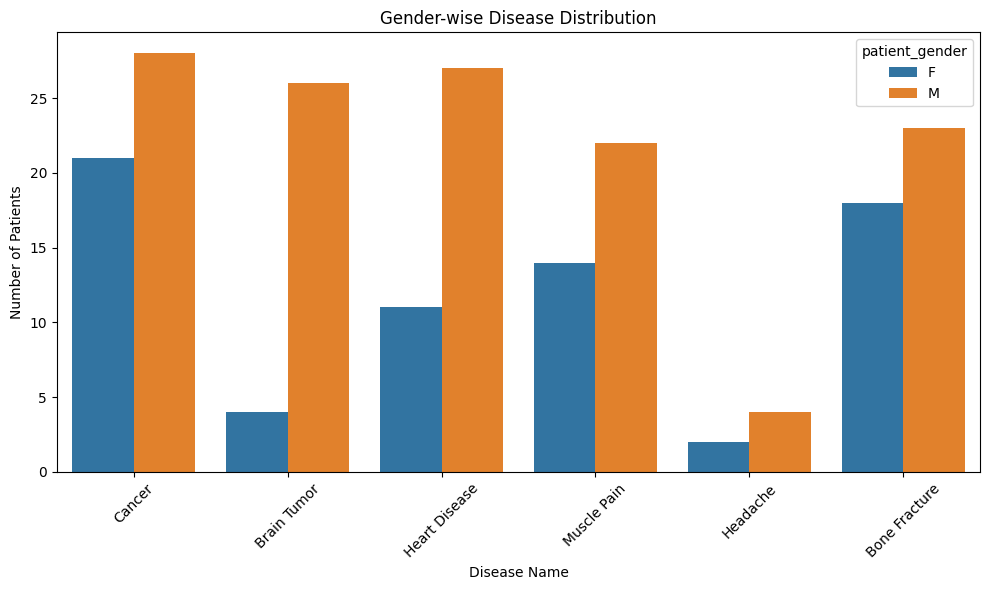

In [51]:
#Gender wise disease distribution

plt.figure(figsize=(10,6))
sns.countplot(data=new_data, x='disease_name', hue='patient_gender')
plt.title("Gender-wise Disease Distribution")
plt.xlabel("Disease Name")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


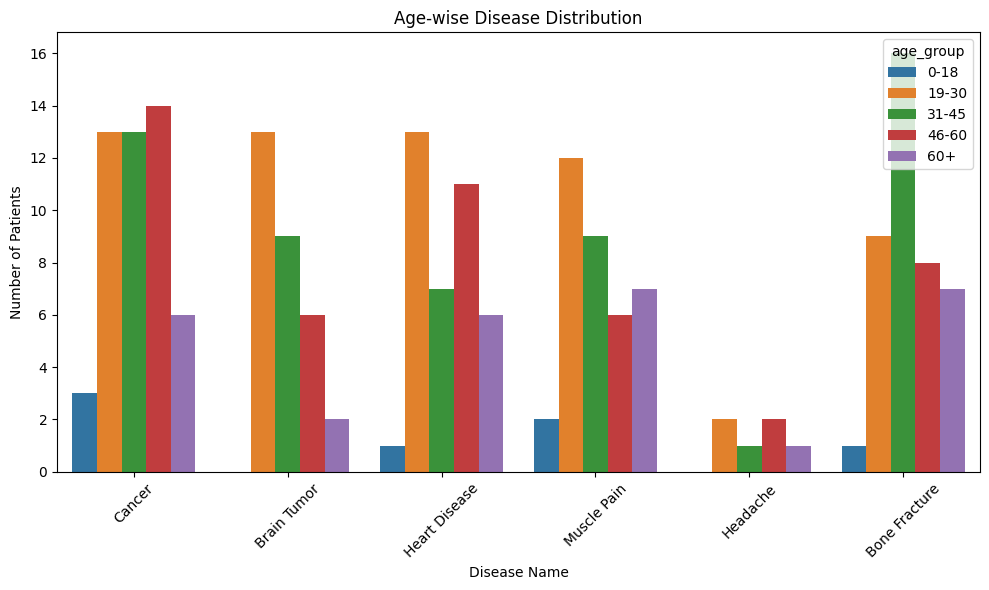

In [52]:
#Age wise diseases distribution

# Create age groups
bins = [0, 18, 30, 45, 60, 100]
labels = ['0-18', '19-30', '31-45', '46-60', '60+']
new_data['age_group'] = pd.cut(new_data['patient_age'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))
sns.countplot(data=new_data, x='disease_name', hue='age_group')
plt.title("Age-wise Disease Distribution")
plt.xlabel("Disease Name")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [53]:
#doctors performance (Patient treated vs recovered)

# Total patients treated
treated = new_data.groupby('doctor_spaecialization')['treatment_id'].count().rename('patients_treated')

# Total recovered patients
recovered = new_data[new_data['recovery_status'] == 'Recovered'].groupby('doctor_spaecialization')['treatment_id'].count().rename('patients_recovered')

# Merge results
doctor_perf = pd.concat([treated, recovered], axis=1).fillna(0)
doctor_perf['recovery_rate (%)'] = (doctor_perf['patients_recovered'] / doctor_perf['patients_treated']) * 100

print(doctor_perf.sort_values(by='recovery_rate (%)', ascending=False))


                        patients_treated  patients_recovered  \
doctor_spaecialization                                         
Oncology                              32                   5   
Pediatrics                            98                  12   
Dermatology                           70                   6   

                        recovery_rate (%)  
doctor_spaecialization                     
Oncology                        15.625000  
Pediatrics                      12.244898  
Dermatology                      8.571429  


# Week 3 - Insights & Prediction

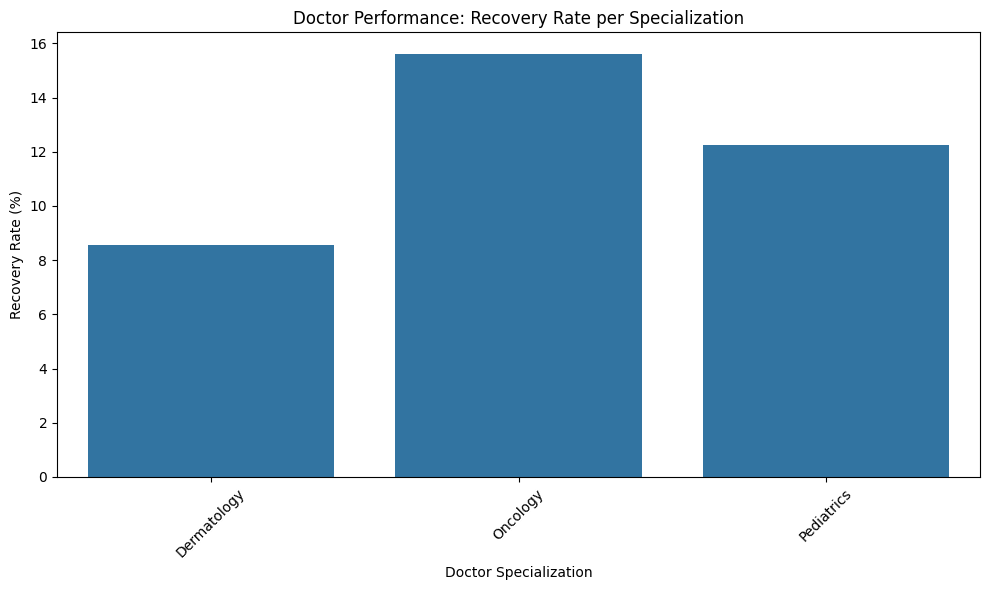

In [54]:
# doctor performance visualization

plt.figure(figsize=(10,6))
sns.barplot(x=doctor_perf.index, y=doctor_perf['recovery_rate (%)'])
plt.title("Doctor Performance: Recovery Rate per Specialization")
plt.ylabel("Recovery Rate (%)")
plt.xlabel("Doctor Specialization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-609260406.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['recovery_status'].eq('Recovered').sum() / len(x)) * 100)
/tmp/ipython-input-609260406.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=disease_perf, x='disease_name', y='recovery_rate (%)', palette='viridis')


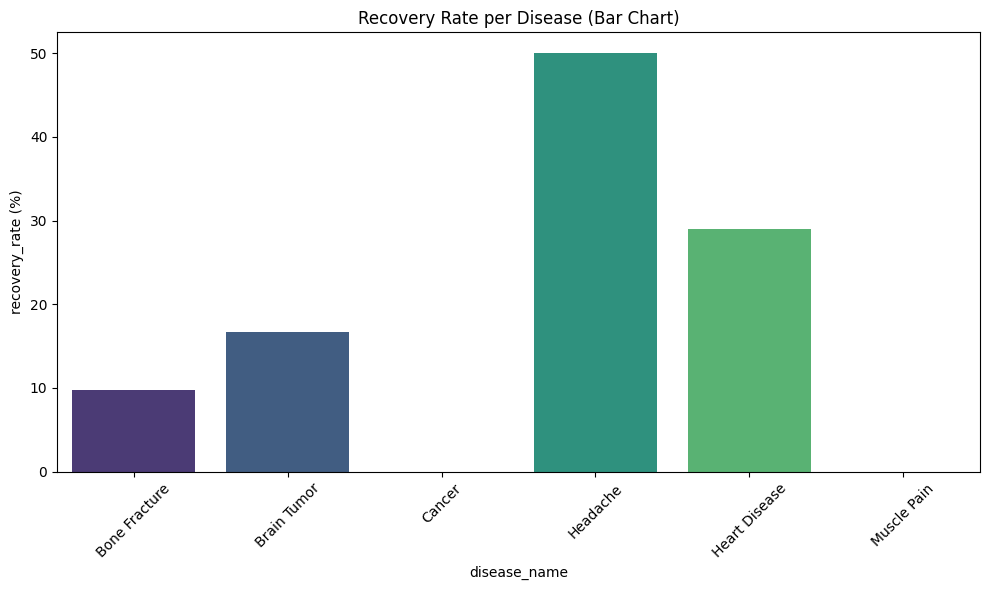

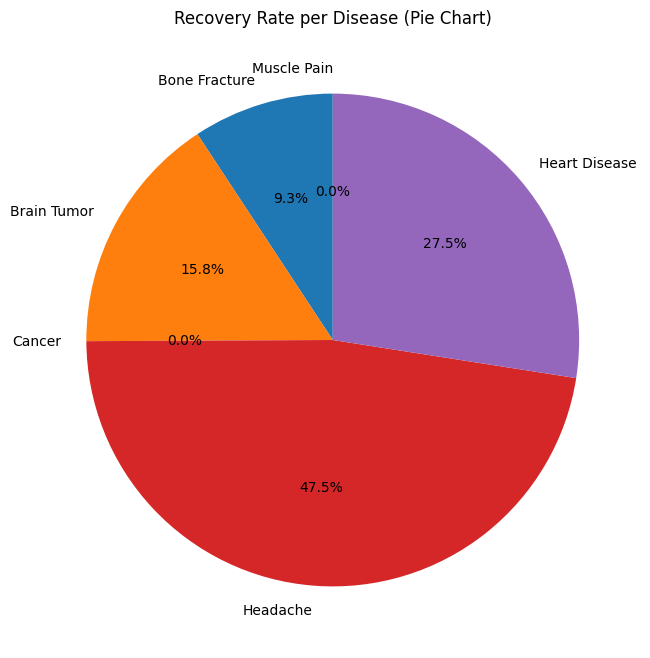

In [55]:
# recovery rate per diseases

disease_perf = (
    new_data.groupby('disease_name')
      .apply(lambda x: (x['recovery_status'].eq('Recovered').sum() / len(x)) * 100)
      .reset_index(name='recovery_rate (%)')
)

plt.figure(figsize=(10,6))
sns.barplot(data=disease_perf, x='disease_name', y='recovery_rate (%)', palette='viridis')
plt.title("Recovery Rate per Disease (Bar Chart)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))
plt.pie(disease_perf['recovery_rate (%)'], labels=disease_perf['disease_name'], autopct='%1.1f%%', startangle=90)
plt.title("Recovery Rate per Disease (Pie Chart)")
plt.show()


In [56]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   treatment_id               200 non-null    object  
 1   treatment_type             200 non-null    object  
 2   cost                       200 non-null    float64 
 3   appointment_status         200 non-null    object  
 4   patient_gender             200 non-null    object  
 5   patient_age                200 non-null    int64   
 6   doctor_spaecialization     200 non-null    object  
 7   doctor_year_of_experience  200 non-null    int64   
 8   disease_name               200 non-null    object  
 9   recovery_duration          200 non-null    int64   
 10  recovery_status            200 non-null    object  
 11  age_group                  200 non-null    category
dtypes: category(1), float64(1), int64(3), object(7)
memory usage: 17.7+ KB


In [57]:
columns = new_data.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {new_data[columns[i]].unique()}\n")

treatment_id values are 
 ['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120'
 'T121' 'T122' 'T123' 'T124' 'T125' 'T126' 'T127' 'T128' 'T129' 'T130'
 'T131' 'T132' 'T133' 'T134' 'T135' 'T136' 'T137' '

disease_name
Cancer           49
Bone Fracture    41
Heart Disease    38
Muscle Pain      36
Brain Tumor      30
Name: count, dtype: int64


/tmp/ipython-input-3035793391.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_diseases.index, y=top5_diseases.values, palette="viridis")


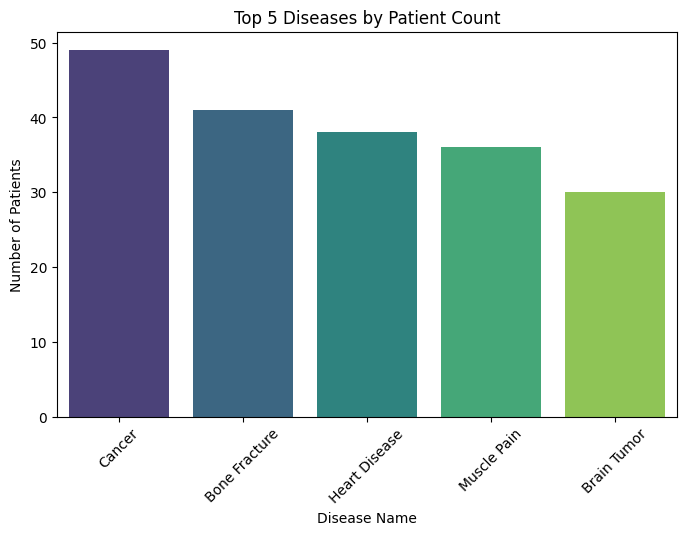

In [58]:
# Count number of patients per disease
disease_counts = new_data['disease_name'].value_counts()

# Get top 5 diseases
top5_diseases = disease_counts.head(5)

print(top5_diseases)

plt.figure(figsize=(8,5))
sns.barplot(x=top5_diseases.index, y=top5_diseases.values, palette="viridis")
plt.title("Top 5 Diseases by Patient Count")
plt.xlabel("Disease Name")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()


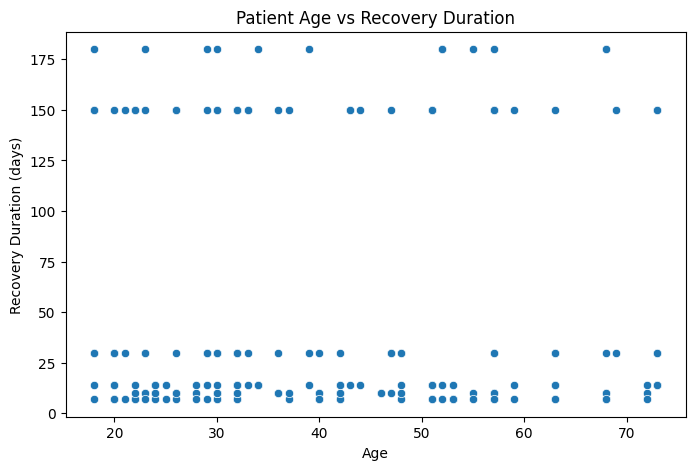

Correlation between age and recovery duration: 0.020692809523226822


In [59]:
# Analyze relation between age and recovery duration
# Scatter Plot (Quick Visual Analysis)

plt.figure(figsize=(8,5))
sns.scatterplot(data=new_data, x='patient_age', y='recovery_duration')
plt.title("Patient Age vs Recovery Duration")
plt.xlabel("Age")
plt.ylabel("Recovery Duration (days)")
plt.show()

# correlation (numerical analysis)
correlation = new_data['patient_age'].corr(new_data['recovery_duration'])
print("Correlation between age and recovery duration:", correlation)


# Encoding categorical values

In [60]:
new_data = new_data.drop(columns=['treatment_id'])
#its only a unique identifier and not needed for model training

In [61]:
from sklearn.preprocessing import LabelEncoder

#label encoding for simple categorical variables with 2–5 values
le = LabelEncoder()
label_cols = ['patient_gender', 'appointment_status', 'recovery_status', 'age_group']

for col in label_cols:
    new_data[col] = le.fit_transform(new_data[col])


In [62]:
new_data[['patient_gender', 'appointment_status', 'recovery_status', 'age_group']].head()

,patient_gender,appointment_status,recovery_status,age_group
0,0,3,1,4
1,1,2,2,2
2,1,0,2,2
3,1,0,2,3
4,1,2,2,3


In [63]:
# One-Hot Encode Multi-Class Categorical Columns
new_data = pd.get_dummies(new_data,
                          columns=['treatment_type', 'doctor_spaecialization', 'disease_name'],
                          drop_first=True,dtype=int)


In [64]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cost                               200 non-null    float64
 1   appointment_status                 200 non-null    int64  
 2   patient_gender                     200 non-null    int64  
 3   patient_age                        200 non-null    int64  
 4   doctor_year_of_experience          200 non-null    int64  
 5   recovery_duration                  200 non-null    int64  
 6   recovery_status                    200 non-null    int64  
 7   age_group                          200 non-null    int64  
 8   treatment_type_ECG                 200 non-null    int64  
 9   treatment_type_MRI                 200 non-null    int64  
 10  treatment_type_Physiotherapy       200 non-null    int64  
 11  treatment_type_X-Ray               200 non-null    int64  

In [65]:
new_data.head()

,cost,appointment_status,patient_gender,patient_age,doctor_year_of_experience,recovery_duration,recovery_status,age_group,treatment_type_ECG,treatment_type_MRI,treatment_type_Physiotherapy,treatment_type_X-Ray,doctor_spaecialization_Oncology,doctor_spaecialization_Pediatrics,disease_name_Brain Tumor,disease_name_Cancer,disease_name_Headache,disease_name_Heart Disease,disease_name_Muscle Pain
0,3941.97,3,0,73,26,150,1,4,0,0,0,0,0,1,0,1,0,0,0
1,4158.44,2,1,42,28,10,2,2,0,1,0,0,0,1,1,0,0,0,0
2,3731.55,0,1,40,28,10,2,2,0,1,0,0,0,1,1,0,0,0,0
3,4799.86,0,1,57,23,10,2,3,0,1,0,0,0,1,1,0,0,0,0
4,582.05,2,1,51,19,7,2,3,1,0,0,0,0,1,0,0,0,1,0


In [66]:
columns = new_data.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {new_data[columns[i]].unique()}\n")

cost values are 
 [3941.97 4158.44 3731.55 4799.86  582.05 1381.    534.03 3413.64 4541.14
 1595.67 4671.66  771.2  4704.96 2082.3   956.39 2686.42 1655.49 1781.93
 1882.8  4113.62 2926.23 1900.88 3246.5  3722.68 1726.81 2360.97 1048.49
 1315.17 3565.03 1316.47 2863.24 3690.71  980.95 3052.9  1654.53 4833.17
 2675.96 4126.97 2976.02  695.36 3349.18 4781.32 3207.25 4186.35 4478.93
 1526.36 1454.2  3249.41 2349.63 4279.38 4550.1  2090.4  1565.92 4012.36
 1736.63 4201.76 2406.82 3503.97  929.91 3307.37 2532.95 3139.74 1256.06
 3815.93 4382.59 1475.33  930.72  606.37 3388.87 3231.92 2960.14 1543.76
 2259.08 3175.14 2735.45 4945.03 1113.98 3628.15 2319.43 2426.9  3729.19
 3615.96 4960.65 1077.77  968.49 3759.52 3102.74 1733.72  857.39  885.46
 4523.86 1363.4  1955.17 1519.95 2097.48  812.41 2835.77  804.26 4101.6
 1551.7  2930.05 4460.36 3428.95 2898.31 1959.5  1998.51 3512.69 4973.63
 3478.28 3010.03 3787.93 2593.43  770.64 3030.34 4809.31 1288.86 3605.02
 1404.2  2911.22  935.04 2526.67 3

In [67]:
from sklearn.preprocessing import StandardScaler

# Columns to standardize
cols_to_scale = ['cost', 'patient_age', 'doctor_year_of_experience','appointment_status', 'recovery_duration', 'recovery_status','age_group']

# Initialize scaler
scaler = StandardScaler()

# Create a copy of the original data
scaled_data = new_data.copy()

# Fit and transform the columns in the new DataFrame
scaled_data[cols_to_scale] = scaler.fit_transform(scaled_data[cols_to_scale])

# Check the first few rows of the scaled DataFrame
scaled_data.head()


,cost,appointment_status,patient_gender,patient_age,doctor_year_of_experience,recovery_duration,recovery_status,age_group,treatment_type_ECG,treatment_type_MRI,treatment_type_Physiotherapy,treatment_type_X-Ray,doctor_spaecialization_Oncology,doctor_spaecialization_Pediatrics,disease_name_Brain Tumor,disease_name_Cancer,disease_name_Headache,disease_name_Heart Disease,disease_name_Muscle Pain
0,0.915702,1.317841,0,2.010253,0.758564,1.614342,-0.984102,1.663176,0,0,0,0,0,1,0,1,0,0,0
1,1.082877,0.430406,1,0.078216,1.097209,-0.644607,0.121631,-0.130006,0,1,0,0,0,1,1,0,0,0,0
2,0.753200,-1.344464,1,-0.046431,1.097209,-0.644607,0.121631,-0.130006,0,1,0,0,0,1,1,0,0,0,0
3,1.578229,-1.344464,1,1.013073,0.250597,-0.644607,0.121631,0.766585,0,1,0,0,0,1,1,0,0,0,0
4,-1.679079,0.430406,1,0.639130,-0.426692,-0.693014,0.121631,0.766585,1,0,0,0,0,1,0,0,0,1,0


In [68]:
scaled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cost                               200 non-null    float64
 1   appointment_status                 200 non-null    float64
 2   patient_gender                     200 non-null    int64  
 3   patient_age                        200 non-null    float64
 4   doctor_year_of_experience          200 non-null    float64
 5   recovery_duration                  200 non-null    float64
 6   recovery_status                    200 non-null    float64
 7   age_group                          200 non-null    float64
 8   treatment_type_ECG                 200 non-null    int64  
 9   treatment_type_MRI                 200 non-null    int64  
 10  treatment_type_Physiotherapy       200 non-null    int64  
 11  treatment_type_X-Ray               200 non-null    int64  

In [69]:
columns = new_data.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {scaled_data[columns[i]].unique()}\n")

cost values are 
 [ 0.91570221  1.08287653  0.75320016  1.57822901 -1.67907921 -1.06207029
 -1.71616384  0.50768629  1.37842608 -0.89628607  1.47922338 -1.53300344
  1.50494013 -0.520474   -1.38998588 -0.05392737 -0.85008859 -0.75244217
 -0.67454281  1.04826317  0.13127184 -0.66058008  0.37860828  0.74635008
 -0.79500995 -0.30526419 -1.31885937 -1.11290914  0.62460096 -1.11190518
  0.08262626  0.72166045 -1.37101881  0.22909589 -0.85082997  1.60395348
 -0.06200536  1.05857304  0.1697234  -1.59157276  0.45790545  1.56391103
  0.3482965   1.10443072  1.33038287 -0.94981243 -1.00553978  0.3808556
 -0.31402178  1.17627544  1.38534566 -0.51421857 -0.91926124  0.97006263
 -0.78742621  1.11633147 -0.26985539  0.57744586 -1.41043571  0.42561665
 -0.17244838  0.29616023 -1.1585583   0.8183647   1.25598192 -0.98922161
 -1.40981017 -1.66029749  0.48855704  0.36734852  0.15745968 -0.93637485
 -0.38395126  0.32349875 -0.01606274  1.69034013 -1.2682831   0.67334695
 -0.33734448 -0.25434811  0.751377

In [70]:
# Dividing dataset into test and train
# Dividing dataset into X and Y that is input and target variables

from sklearn.model_selection import train_test_split

# X = input features, y = target
X = scaled_data.drop('recovery_duration', axis=1)
y = scaled_data['recovery_duration']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # data and target
    test_size=0.2,     # 20% data for testing, 80% for training
    random_state=42    # for reproducibility
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (160, 18)
X_test shape: (40, 18)
y_train shape: (160,)
y_test shape: (40,)


In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Root Mean Squared Error (RMSE): 0.07626681099021154
R² Score: 0.9914560770658586


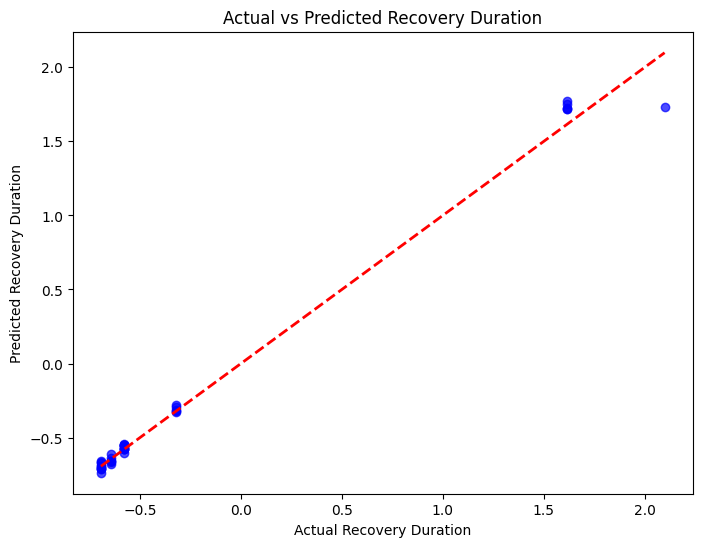

In [72]:

# Predict recovery duration on the test set
y_pred = lr_model.predict(X_test)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Recovery Duration")
plt.ylabel("Predicted Recovery Duration")
plt.title("Actual vs Predicted Recovery Duration")
plt.show()


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# y_test = actual values
# y_pred = predicted values

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Absolute Error (MAE): 0.04111235471677961
Mean Squared Error (MSE): 0.005816626458616652
Root Mean Squared Error (RMSE): 0.07626681099021154
R² Score: 0.9914560770658586


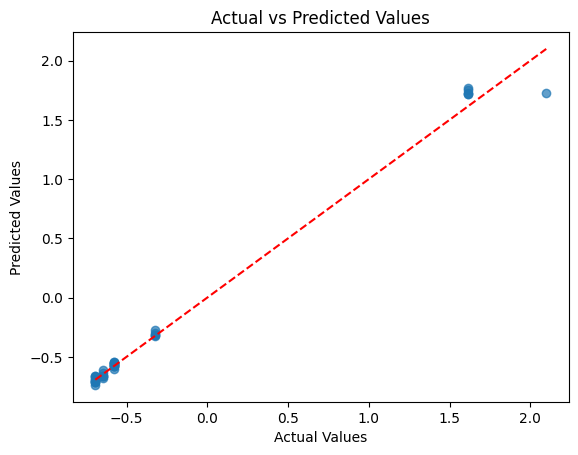

In [74]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


## Week 4 Dashboard and visualization

In [75]:
scaled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cost                               200 non-null    float64
 1   appointment_status                 200 non-null    float64
 2   patient_gender                     200 non-null    int64  
 3   patient_age                        200 non-null    float64
 4   doctor_year_of_experience          200 non-null    float64
 5   recovery_duration                  200 non-null    float64
 6   recovery_status                    200 non-null    float64
 7   age_group                          200 non-null    float64
 8   treatment_type_ECG                 200 non-null    int64  
 9   treatment_type_MRI                 200 non-null    int64  
 10  treatment_type_Physiotherapy       200 non-null    int64  
 11  treatment_type_X-Ray               200 non-null    int64  

# DisplayKPIs: average recovery rate, top doctors, and critical diseases

In [76]:
df = pd.read_csv("/content/cleaned_medical_data.csv")
df.head()

,treatment_id,appointment_id,treatment_type,cost,patient_id,doctor_id,appointment_status,patient_gender,patient_age,doctor_first_name,doctor_last_name,doctor_spaecialization,doctor_year_of_experience,disease_name,recovery_duration,recovery_status
0,T001,A001,Chemotherapy,3941.97,P034,D009,Scheduled,F,73,Sarah,Smith,Pediatrics,26,Cancer,150,In Progress
1,T002,A002,MRI,4158.44,P032,D004,No-show,M,42,David,Jones,Pediatrics,28,Brain Tumor,10,Not Treated
2,T003,A003,MRI,3731.55,P048,D004,Cancelled,M,40,David,Jones,Pediatrics,28,Brain Tumor,10,Not Treated
3,T004,A004,MRI,4799.86,P025,D006,Cancelled,M,57,Alex,Davis,Pediatrics,23,Brain Tumor,10,Not Treated
4,T005,A005,ECG,582.05,P040,D003,No-show,M,51,Jane,Smith,Pediatrics,19,Heart Disease,7,Not Treated


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   treatment_id               200 non-null    object 
 1   appointment_id             200 non-null    object 
 2   treatment_type             200 non-null    object 
 3   cost                       200 non-null    float64
 4   patient_id                 200 non-null    object 
 5   doctor_id                  200 non-null    object 
 6   appointment_status         200 non-null    object 
 7   patient_gender             200 non-null    object 
 8   patient_age                200 non-null    int64  
 9   doctor_first_name          200 non-null    object 
 10  doctor_last_name           200 non-null    object 
 11  doctor_spaecialization     200 non-null    object 
 12  doctor_year_of_experience  200 non-null    int64  
 13  disease_name               200 non-null    object 

In [78]:
columns = df.columns
for i in range(len(columns)):
  print(f"{columns[i]} values are \n {df[columns[i]].unique()}\n")

treatment_id values are 
 ['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120'
 'T121' 'T122' 'T123' 'T124' 'T125' 'T126' 'T127' 'T128' 'T129' 'T130'
 'T131' 'T132' 'T133' 'T134' 'T135' 'T136' 'T137' '

In [79]:
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact


In [80]:
# Count recovered patients
recovered_count = df[df['recovery_status'] == 'Recovered'].shape[0]

# Total patients
total_patients = df.shape[0]

# Average Recovery Rate (%)
avg_recovery_rate = (recovered_count / total_patients) * 100

print(f"Average Recovery Rate: {avg_recovery_rate:.2f}%")


Average Recovery Rate: 11.50%


In [81]:
top_doctors = (
    df[df['recovery_status'] == 'Recovered']
    .groupby(['doctor_id', 'doctor_first_name', 'doctor_last_name'])
    .size()
    .reset_index(name='RecoveredPatients')
    .sort_values(by='RecoveredPatients', ascending=False)
)

# Show top 5 doctors
top_doctors_head = top_doctors.head(5)
print(top_doctors_head)


  doctor_id doctor_first_name doctor_last_name  RecoveredPatients
5      D006              Alex            Davis                  4
0      D001             David           Taylor                  3
1      D002              Jane            Davis                  3
8      D010             Linda           Wilson                  3
3      D004             David            Jones                  3


In [82]:
critical_diseases = (
    df[df['recovery_status'] != 'Recovered']
    .groupby('disease_name')
    .size()
    .reset_index(name='CriticalCount')
    .sort_values(by='CriticalCount', ascending=False)
)

# Show top 5 critical diseases
critical_diseases_head = critical_diseases.head(5)
print(critical_diseases_head)


    disease_name  CriticalCount
2         Cancer             49
0  Bone Fracture             37
5    Muscle Pain             36
4  Heart Disease             27
1    Brain Tumor             25


In [83]:
# Average Recovery Rate Card
fig1 = go.Figure(go.Indicator(
    mode="gauge+number",
    value=avg_recovery_rate,
    title={'text': "Average Recovery Rate (%)"},
    gauge={'axis': {'range': [0, 100]}}
))
fig1.show()

# Top Doctors Bar Chart
fig2 = px.bar(top_doctors_head,
              x='doctor_first_name',
              y='RecoveredPatients',
              color='RecoveredPatients',
              title='Top Doctors by Recovered Patients')
fig2.show()

# Critical Diseases Bar Chart
fig3 = px.bar(critical_diseases_head,
              x='disease_name',
              y='CriticalCount',
              color='CriticalCount',
              title='Critical Diseases (Patients Not Recovered)')
fig3.show()


In [84]:
def filter_by_specialization(specialization):
    filtered_df = df[df['doctor_spaecialization'] == specialization]

    recovered_count = filtered_df[filtered_df['recovery_status'] == 'Recovered'].shape[0]
    total_patients = filtered_df.shape[0]
    avg_recovery_rate = (recovered_count / total_patients) * 100

    print(f"Specialization: {specialization}")
    print(f"Average Recovery Rate: {avg_recovery_rate:.2f}%")

    top_docs = (filtered_df[filtered_df['recovery_status'] == 'Recovered']
                .groupby(['doctor_first_name'])
                .size()
                .sort_values(ascending=False)
                .head(5))
    print("\nTop Doctors:")
    print(top_docs)

    critical_dis = (filtered_df[filtered_df['recovery_status'] != 'Recovered']
                    .groupby('disease_name')
                    .size()
                    .sort_values(ascending=False)
                    .head(5))
    print("\nCritical Diseases:")
    print(critical_dis)

interact(filter_by_specialization, specialization=df['doctor_spaecialization'].unique())


interactive(children=(Dropdown(description='specialization', options=('Pediatrics', 'Oncology', 'Dermatology')…

<function __main__.filter_by_specialization(specialization)>